In [6]:
%load_ext autoreload
%autoreload 2

import os, ctypes
from glob import glob
append_ld_library_path = "~/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
LD_LIBRARY_PATH = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{append_ld_library_path}:{LD_LIBRARY_PATH}" if LD_LIBRARY_PATH else append_ld_library_path

cublas_dir = "/home/ubuntu/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
for pat in ["libcublas.so*", "libcublasLt.so*", "libcudart.so*"]:
    for lib in sorted(glob(os.path.join(cublas_dir, pat))):
        try:
            ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
        except OSError as e:
            print(f"Warning: could not load {lib}: {e}")

import torch
import torch._dynamo
torch._dynamo.config.suppress_errors = True

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns
import os
import pickle
from tqdm import tqdm
from glob import glob
from copy import deepcopy

from scipy.spatial.distance import squareform, pdist
from scipy.stats import wilcoxon
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# import gemmi
from Bio.PDB import MMCIFParser
from Bio import pairwise2

from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import MSA, aa2tok_d, prepare_msa_masks
from MSA_Pairformer.plotting import eval_hetero_oligomer
from MSA_Pairformer.utils import get_p_at_k, get_p_at_l

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')
print(f"Using device: {torch.cuda.get_device_name(device)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: NVIDIA GH200 480GB


In [7]:
target_data_file = "../../data/Figure2_heterooligomer_contact_prediction/target_data.pkl"
with open(target_data_file, "rb") as oFile:
    target_data_d = pickle.load(oFile)
print("{} targets loaded".format(len(target_data_d)))

30 targets loaded


# 1. Predict multimer contacts with MSA Pairformer

In [3]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
msa_pairformer = MSAPairformer.from_pretrained(
    device=device
)
msa_pairformer.eval()
print(f"Using device: {torch.cuda.get_device_name(device)}")

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Using cuEquivariance for triangle multiplicative update
Using device: NVIDIA GH200 480GB


In [4]:
nSeqs = 512
for target in tqdm(target_data_d.keys()):
    # Load alignment
    msa_file = target_data_d[target]['msa_file']
    with open(msa_file, "r") as oFile:
        query_seq = oFile.readlines()[1].strip()
    np.random.seed(42)
    msa_obj = MSA(
        msa_file_path = msa_file,
        max_seqs = nSeqs,
        max_length = np.inf,
        max_tokens = np.inf,
        diverse_select_method = "hhfilter",
        hhfilter_kwargs = {"qid": 30},
    )
    msa_tokenized_t = msa_obj.diverse_tokenized_msa
    msa_onehot_t = torch.nn.functional.one_hot(msa_tokenized_t, num_classes=len(aa2tok_d)).unsqueeze(0).float().to(device)
    chain_break_idx = target_data_d[target]['chain_break']
    mask, msa_mask, full_mask, pairwise_mask = prepare_msa_masks(msa_obj.diverse_tokenized_msa.unsqueeze(0))
    mask, msa_mask, full_mask, pairwise_mask = mask.to(device), msa_mask.to(device), full_mask.to(device), pairwise_mask.to(device)
    with torch.no_grad():
        res = msa_pairformer.predict_cb_contacts(
            msa = msa_onehot_t,
            mask = mask,
            msa_mask = msa_mask,
            full_mask = full_mask,
            pairwise_mask = pairwise_mask,
            complex_chain_break_indices = [[chain_break_idx]],
            return_seq_weights = False
        )
        pred_contacts_a = res['predicted_cb_contacts'][0].cpu().numpy()
    np.save(f"results/Figure2_heterooligomer_contact_prediction/msa_pairformer/{target}.npy", pred_contacts_a)

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [02:28<00:00,  4.95s/it]


In [ ]:
# No genomic distance filter
nSeqs = 512
for target in tqdm(target_data_d.keys()):
    # Load alignment
    msa_file = target_data_d[target]['msa_file'].replace("/msas/", "/unpaired_msas/")
    with open(msa_file, "r") as oFile:
        query_seq = oFile.readlines()[1].strip()
    np.random.seed(42)
    msa_obj = MSA(
        msa_file_path = msa_file,
        max_seqs = nSeqs,
        max_length = np.inf,
        max_tokens = np.inf,
        diverse_select_method = "hhfilter",
        hhfilter_kwargs = {"qid": 30},
    )
    msa_tokenized_t = msa_obj.diverse_tokenized_msa
    msa_onehot_t = torch.nn.functional.one_hot(msa_tokenized_t, num_classes=len(aa2tok_d)).unsqueeze(0).float().to(device)
    chain_break_idx = target_data_d[target]['chain_break']
    mask, msa_mask, full_mask, pairwise_mask = prepare_msa_masks(msa_obj.diverse_tokenized_msa.unsqueeze(0))
    mask, msa_mask, full_mask, pairwise_mask = mask.to(device), msa_mask.to(device), full_mask.to(device), pairwise_mask.to(device)
    with torch.no_grad():
        res = msa_pairformer.predict_cb_contacts(
            msa = msa_onehot_t,
            mask = mask,
            msa_mask = msa_mask,
            full_mask = full_mask,
            pairwise_mask = pairwise_mask,
            complex_chain_break_indices = [[chain_break_idx]],
            return_seq_weights = False
        )
        pred_contacts_a = res['predicted_cb_contacts'][0].cpu().numpy()
    np.save(f"results/Figure2_heterooligomer_contact_prediction/msa_pairformer_no_dgene/{target}.npy", pred_contacts_a)

# 2. Evaluate predictions

In [8]:
all_precision_d = {
    "MSA Pairformer": {},
    "MSA Pairformer (No genomic distance filter)": {},
    "MSA Transformer": {},
    "gLM2": {},
    "ESMC": {},
    "E1": {},
    "Inverse covariance": {}
}
for i, target in enumerate(tqdm(sorted(list(target_data_d.keys())))):
    # Load predictions
    full_chain_break_pos = target_data_d[target]['chain_break']
    pred_mask_a = target_data_d[target]['msa_mask']
    pred_contacts_a = np.load(f"results/msa_pairformer/{target}.npy")[pred_mask_a][:, pred_mask_a]
    pred_contacts_no_dgene_a = np.load(f"results/msa_pairformer_no_dgene/{target}.npy")[pred_mask_a][:, pred_mask_a]
    glm2_contacts_a = np.loadtxt(f"results/glm2/{target}_coevolution.txt")[pred_mask_a][:, pred_mask_a]
    esmc_contacts_a = np.loadtxt(f"results/esmc/{target}.esmc_600m.txt")[pred_mask_a][:, pred_mask_a]
    e1_path = f"results/e1/{target}.txt"
    e1_contacts_a = np.loadtxt(e1_path)[pred_mask_a][:, pred_mask_a]
    msa_transformer_path = f"results/msa_transformer/{target}_msa_transformer.txt"
    if os.path.exists(msa_transformer_path): # Not all complexes fall below the 1024 length limit of MSA Transformer
        msa_transformer_contacts_a = np.loadtxt(msa_transformer_path)[pred_mask_a][:, pred_mask_a]
    else:
        msa_transformer_contacts_a = None
    inv_cov_a = np.load(f"results/inverse_covariance/{target}.npy")[pred_mask_a][:, pred_mask_a]
    # Load crystal structure contacts
    contacts_a = deepcopy(target_data_d[target]['contacts_a'])
    cif_mask_a = target_data_d[target]['cif_mask']
    contacts_a = contacts_a[cif_mask_a][:, cif_mask_a]
    # Get inter-chain contacts
    chain_break_pos = pred_mask_a[:full_chain_break_pos].sum()
    # Evaluate and plot
    if msa_transformer_contacts_a is not None:
        num_plots = 5
    else:
        num_plots = 4
    pred_cons_d = {
        "MSA Pairformer": pred_contacts_a,
        "MSA Pairformer (No genomic distance filter)": pred_contacts_no_dgene_a,
        "MSA Transformer": msa_transformer_contacts_a,
        "gLM2": glm2_contacts_a,
        "ESMC": esmc_contacts_a,
        "E1": e1_contacts_a,
        "Inverse covariance": inv_cov_a
    }
    for plot_idx, (method_label, pred_cons) in enumerate(pred_cons_d.items()):
        if pred_cons is None:
            continue
        monomer_1_p_at_k = get_p_at_k(contacts_a[:chain_break_pos, :chain_break_pos], pred_cons[:chain_break_pos, :chain_break_pos], minsep=24, upper_triangle=True)
        monomer_1_p_at_l = get_p_at_l(contacts_a[:chain_break_pos, :chain_break_pos], pred_cons[:chain_break_pos, :chain_break_pos], minsep=24, upper_triangle=True)
        monomer_2_p_at_k = get_p_at_k(contacts_a[chain_break_pos:, chain_break_pos:], pred_cons[chain_break_pos:, chain_break_pos:], minsep=24, upper_triangle=True)
        monomer_2_p_at_l = get_p_at_l(contacts_a[chain_break_pos:, chain_break_pos:], pred_cons[chain_break_pos:, chain_break_pos:], minsep=24, upper_triangle=True)
        hetero_p_at_k = get_p_at_k(contacts_a[chain_break_pos:, :chain_break_pos], pred_cons[chain_break_pos:, :chain_break_pos], minsep=0, upper_triangle=False)
        precision_d = {
            "chain_0": monomer_1_p_at_k,
            "chain_1": monomer_2_p_at_k,
            "chain_0_l": monomer_1_p_at_l,
            "chain_1_l": monomer_2_p_at_l,
            "interface": hetero_p_at_k
        }
        all_precision_d[method_label][target] = precision_d

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:08<00:00,  3.48it/s]


Wilcoxon signed-rank test p-value: 7.835209088796206e-05
dGene = 1:
	Median: 0.50
	Mean: 0.46
	Std: 0.19
No genomic distance filter:
	Median: 0.21
	Mean: 0.26
	Std: 0.22


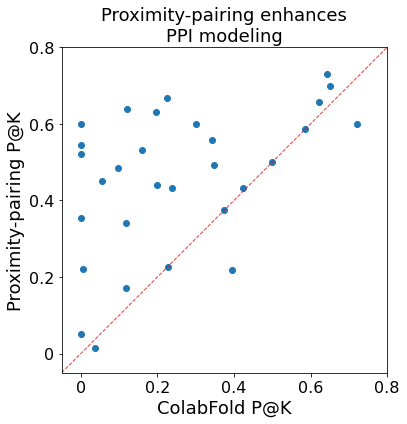

In [10]:
y_vals = np.array([all_precision_d['MSA Pairformer'][target]['interface'] for target in all_precision_d['MSA Pairformer'].keys()])
x_vals = np.array([all_precision_d['MSA Pairformer (No genomic distance filter)'][target]['interface'] for target in all_precision_d['MSA Pairformer'].keys()])
nan_idx = np.isnan(x_vals) | np.isnan(y_vals)
x_vals = x_vals[~nan_idx]
y_vals = y_vals[~nan_idx]

f, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(x_vals, y_vals)

# Add x = y line
min_val = min(np.min(x_vals), np.min(y_vals))
max_val = max(np.max(x_vals), np.max(y_vals))
ax.plot([-0.05, 0.8], [-0.05, 0.8], 'r--', alpha=0.8, linewidth=1)

# Make square
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect('equal', adjustable='box')
ax.set_ylim(-0.05, 0.8)
ax.set_xlim(-0.05, 0.8)
ax.set_xlabel("ColabFold P@K", size=18)
ax.set_ylabel("Proximity-pairing P@K", size=18)
ax.set_title("Proximity-pairing enhances\nPPI modeling", size=18)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax.set_xticklabels([0, 0.2, 0.4, 0.6, 0.8], size=16)
ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8], size=16)
_, p_val = wilcoxon(x_vals, y_vals)
print(f"Wilcoxon signed-rank test p-value: {p_val}")
print(f"dGene = 1:\n\tMedian: {np.median(y_vals):.2f}\n\tMean: {np.mean(y_vals):.2f}\n\tStd: {np.std(y_vals):.2f}")
print(f"No genomic distance filter:\n\tMedian: {np.median(x_vals):.2f}\n\tMean: {np.mean(x_vals):.2f}\n\tStd: {np.std(x_vals):.2f}")
f.tight_layout()

[Text(0, 0.0, '0'),
 Text(0, 0.2, '0.2'),
 Text(0, 0.4, '0.4'),
 Text(0, 0.6, '0.6'),
 Text(0, 0.8, '0.8')]

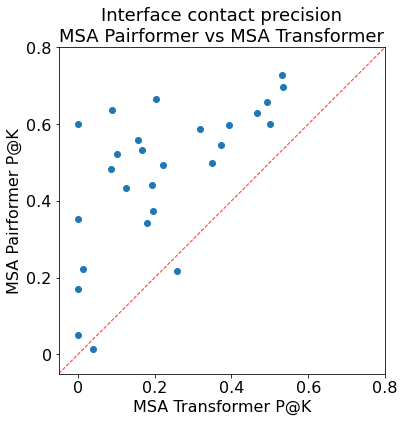

In [14]:
x_vals = np.array([all_precision_d['MSA Transformer'][target]['interface'] for target in all_precision_d['MSA Transformer'].keys()])
y_vals = np.array([all_precision_d['MSA Pairformer'][target]['interface'] for target in all_precision_d['MSA Transformer'].keys()])

f, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(x_vals, y_vals)

# Add x = y line
min_val = min(np.min(x_vals), np.min(y_vals))
max_val = max(np.max(x_vals), np.max(y_vals))
ax.plot([-0.05, 0.8], [-0.05, 0.8], 'r--', alpha=0.8, linewidth=1)

# Make square
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect('equal', adjustable='box')
ax.set_ylim(-0.05, 0.8)
ax.set_xlim(-0.05, 0.8)
ax.set_xlabel("MSA Transformer P@K", size=16)
ax.set_ylabel("MSA Pairformer P@K", size=16)
ax.set_title("Interface contact precision\nMSA Pairformer vs MSA Transformer", size=18)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax.set_xticklabels([0, 0.2, 0.4, 0.6, 0.8], size=16)
ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8], size=16)

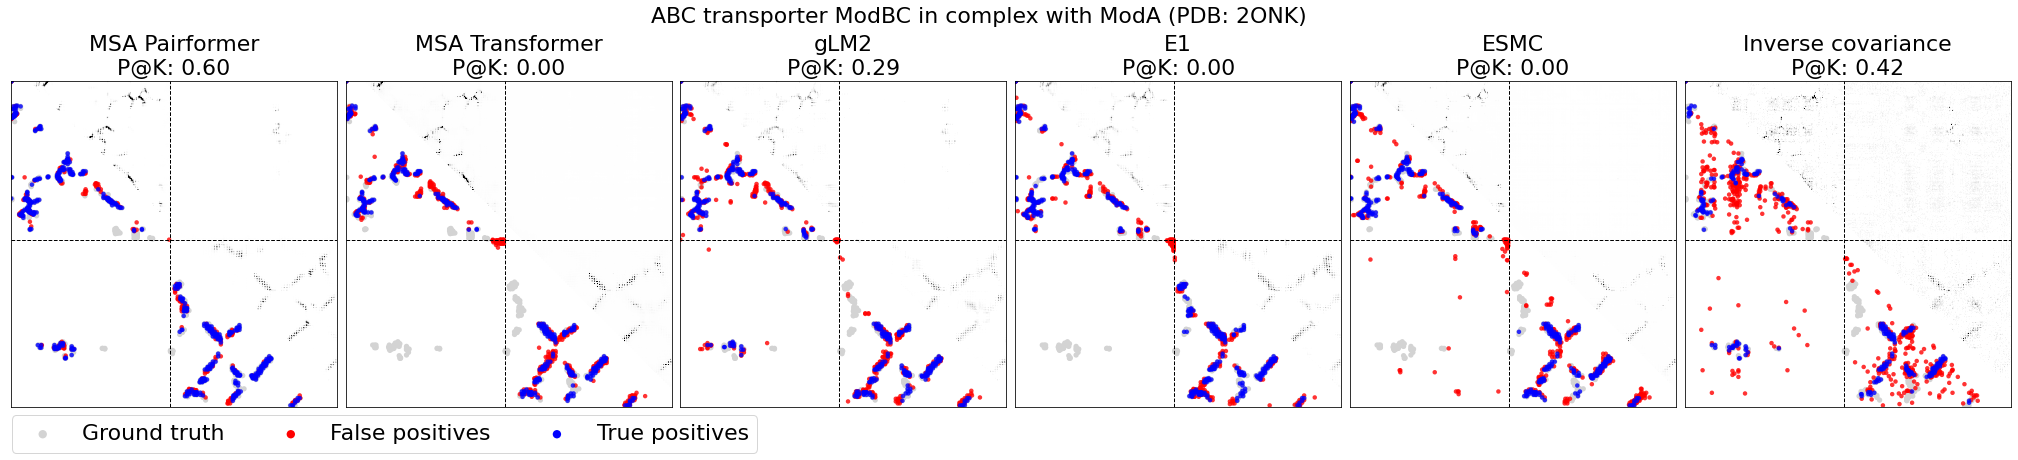

In [11]:
title_str = "ABC transporter ModBC in complex with ModA (PDB: 2ONK)"
vmin_d = {
    "MSA Pairformer": None,
    "gLM2": 0,
    "E1": 0,
    "ESMC": None,
    "MSA Transformer": None,
    "Inverse covariance": 0,
}
# Load predictions
target = "2ONK_A_2ONK_C"
pred_mask_a = target_data_d[target]['msa_mask']
pred_contacts_a = np.load(f"results/msa_pairformer/{target}.npy")[pred_mask_a][:, pred_mask_a]
glm2_contacts_a = np.loadtxt(f"results/glm2/{target}_coevolution.txt")[pred_mask_a][:, pred_mask_a]
esmc_contacts_a = np.loadtxt(f"results/esmc/{target}.esmc_600m.txt")[pred_mask_a][:, pred_mask_a]
e1_contacts_a = np.loadtxt(f"results/e1/{target}.txt")[pred_mask_a][:, pred_mask_a]
inv_cov_a = np.load(f"results/inverse_covariance/{target}.npy")[pred_mask_a][:, pred_mask_a]
msa_transformer_contacts_a = np.loadtxt(f"results/msa_transformer/{target}_msa_transformer.txt")[pred_mask_a][:, pred_mask_a]

# Load crystal structure contacts
contacts_a = deepcopy(target_data_d[target]['contacts_a'])
cif_mask_a = target_data_d[target]['cif_mask']
contacts_a = contacts_a[cif_mask_a][:, cif_mask_a]
chain_break_pos = pred_mask_a[:target_data_d[target]['chain_break']].sum()

# Evaluate and plot
num_plots = 5
pred_cons_d = {
    "MSA Pairformer": pred_contacts_a,
    "MSA Transformer": msa_transformer_contacts_a,
    "gLM2": glm2_contacts_a,
    "E1": e1_contacts_a,
    "ESMC": esmc_contacts_a,
    "Inverse covariance": inv_cov_a
}
methods_order_l = ["MSA Pairformer", "MSA Transformer", "gLM2", "E1", "ESMC", "Inverse covariance"]
f, ax = plt.subplots(1, len(methods_order_l), figsize=(6 * len(methods_order_l), 6))
f.patch.set_facecolor('white')
f.subplots_adjust(wspace=0)  # Decrease horizontal spacing between subplots
ax_idx_d = {
    "MSA Pairformer": 0,
    "MSA Transformer": 1,
    "gLM2": 2,
    "E1": 3,
    "ESMC": 4,
    "Inverse covariance": 5,
}
for plot_idx, method_label in enumerate(methods_order_l):
    pred_cons = pred_cons_d[method_label]
    if pred_cons is None:
        continue
    vmax = np.sort(pred_cons.flatten())[int(-pred_cons.shape[0] * 2)]
    vmin = vmin_d[method_label]
    f, _, precision_d = eval_hetero_oligomer(
        cons = [contacts_a, pred_cons],
        chain_break_pos = chain_break_pos,
        L = 1,
        monomer_minsep = 24,
        cutoffs = [None, None],
        ss = [28, 20],
        cc = ['lightgray', 'blue'],
        f = f,
        ax = ax[ax_idx_d[method_label]],
        vmax = vmax,
        vmin = vmin,
        monomer_p_at_k = True,
    )
    ax[ax_idx_d[method_label]].axhline(y=chain_break_pos, xmin=0, xmax=1, color='black', linestyle='--', linewidth=1)
    ax[ax_idx_d[method_label]].axvline(x=chain_break_pos, ymin=0, ymax=1, color='black', linestyle='--', linewidth=1)
    interface_precision = f"{precision_d['interface']:.2f}" if 'interface' in precision_d else "No interface contacts"
    ax[ax_idx_d[method_label]].set_title(f"{method_label}\nP@K: {interface_precision}", size=22)
    ax[ax_idx_d[method_label]].set_ylabel('')
    ax[ax_idx_d[method_label]].set_yticklabels([])
    all_precision_d[method_label][target] = precision_d
ax[0].legend(bbox_to_anchor=(-0.03, -0.175), loc='lower left', fontsize=22, ncol=3)
f.suptitle(title_str, size=22, y=1.05)
f.savefig(f"results/figures/{target}.with_inv_cov.pdf", dpi=300, bbox_inches='tight')

Median probability of correctly predicted contacts:
MSA Pairformer (interface): 0.56
MSA Transformer (interface): 0.16
MSA Pairformer (monomer): 0.78
MSA Transformer (monomer): 0.46
MSA Pairformer monomer vs interface fold-change: 1.38
MSA Transformer monomer vs interface fold-change: 2.86
MSA Pairformer (monomer no contact): 0.000
MSA Transformer (monomer no contact): 0.006
MSA Pairformer (interface no contact): 0.000
MSA Transformer (interface no contact): 0.005


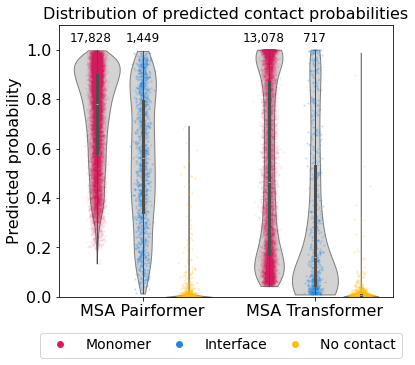

In [9]:
# Cumulative distribution of predicted probabilities for correct contacts in the top K
pairformer_interface_correct_prob_l = []
transformer_interface_correct_prob_l = []
pairformer_monomer_correct_prob_l = []
transformer_monomer_correct_prob_l = []
pairformer_monomer_negative_prob_l = []
transformer_monomer_negative_prob_l = []
pairformer_interface_negative_prob_l = []
transformer_interface_negative_prob_l = []

# MSA Pairformer vs MSA Transformer
for target in target_data_d:
    if target not in all_precision_d['MSA Transformer']: # Skip if target is longer than 1024
        continue
    # Load predictions
    pred_mask_a = target_data_d[target]['msa_mask']
    pairformer_pred_contacts_a = np.load(f"results/msa_pairformer/{target}.npy")[pred_mask_a][:, pred_mask_a]
    transformer_pred_contacts_a = np.loadtxt(f"results/msa_transformer/{target}_msa_transformer.txt")[pred_mask_a][:, pred_mask_a]
    # Load ground truth contacts
    chain_break_pos = pred_mask_a[:target_data_d[target]['chain_break']].sum()
    contacts_a = deepcopy(target_data_d[target]['contacts_a'])
    cif_mask_a = target_data_d[target]['cif_mask']
    contacts_a = contacts_a[cif_mask_a][:, cif_mask_a]
    # Get top K contacts
    pairformer_interface_region_a = pairformer_pred_contacts_a[:chain_break_pos, chain_break_pos:]
    transformer_interface_region_a = transformer_pred_contacts_a[:chain_break_pos, chain_break_pos:]
    gt_interface_region_a = contacts_a[:chain_break_pos, chain_break_pos:]
    # Get top K predictions
    pairformer_interface_flat = pairformer_interface_region_a.flatten()
    transformer_interface_flat = transformer_interface_region_a.flatten()
    gt_interface_flat = gt_interface_region_a.flatten()
    k = gt_interface_flat.sum()
    pairformer_top_k_indices = np.argpartition(pairformer_interface_flat, -k)[-k:]
    transformer_top_k_indices = np.argpartition(transformer_interface_flat, -k)[-k:]
    # Check which predictions are correct
    pairformer_correct_a = gt_interface_flat[pairformer_top_k_indices] == 1
    transformer_correct_a = gt_interface_flat[transformer_top_k_indices] == 1
    # Get predicted probabilities for correct predictions
    pairformer_correct_prob_a = pairformer_interface_flat[pairformer_top_k_indices[np.where(pairformer_correct_a == 1)]]
    transformer_correct_prob_a = transformer_interface_flat[transformer_top_k_indices[np.where(transformer_correct_a == 1)]]
    pairformer_interface_correct_prob_l += list(pairformer_correct_prob_a)
    transformer_interface_correct_prob_l += list(transformer_correct_prob_a)
    # Get predicted probabilities for residue pairs that are not contacts
    pairformer_negative_prob_a = pairformer_interface_region_a[np.where(gt_interface_region_a == 0)]
    transformer_negative_prob_a = transformer_interface_region_a[np.where(gt_interface_region_a == 0)]
    pairformer_interface_negative_prob_l += list(pairformer_negative_prob_a)
    transformer_interface_negative_prob_l += list(transformer_negative_prob_a)

    ### Monomer contacts
    contacts_a = deepcopy(target_data_d[target]['contacts_a'])
    cif_mask_a = target_data_d[target]['cif_mask']
    contacts_a = contacts_a[cif_mask_a][:, cif_mask_a]
    for i in range(2):
        # Subset for monomer region
        chain_start_idx = i * chain_break_pos
        if i == 0:
            chain_end_idx = chain_break_pos
        else:
            chain_end_idx = contacts_a.shape[0]
        pairformer_monomer_region_a = pairformer_pred_contacts_a[chain_start_idx:chain_end_idx, chain_start_idx:chain_end_idx]
        transformer_monomer_region_a = transformer_pred_contacts_a[chain_start_idx:chain_end_idx, chain_start_idx:chain_end_idx]
        gt_monomer_region_a = contacts_a[chain_start_idx:chain_end_idx, chain_start_idx:chain_end_idx]
        # Take upper triangles
        triu_idx = np.triu_indices_from(gt_monomer_region_a, 1)
        longrange_mask = np.abs(triu_idx[0] - triu_idx[1]) >= 24
        filtered_i, filtered_j = triu_idx[0][longrange_mask], triu_idx[1][longrange_mask]
        pairformer_monomer_region_a = pairformer_monomer_region_a[filtered_i, filtered_j]
        transformer_monomer_region_a = transformer_monomer_region_a[filtered_i, filtered_j]
        gt_monomer_region_a = gt_monomer_region_a[filtered_i, filtered_j]
        k = gt_monomer_region_a.sum()
        # Get top K predictions
        pairformer_top_k_indices = np.argpartition(pairformer_monomer_region_a, -k)[-k:]
        transformer_top_k_indices = np.argpartition(transformer_monomer_region_a, -k)[-k:]
        # Check which predictions are correct
        pairformer_correct_a = gt_monomer_region_a[pairformer_top_k_indices] == 1
        transformer_correct_a = gt_monomer_region_a[transformer_top_k_indices] == 1
        # Get predicted probabilities for correct predictions
        pairformer_correct_prob_a = pairformer_monomer_region_a[pairformer_top_k_indices[np.where(pairformer_correct_a == 1)]]
        transformer_correct_prob_a = transformer_monomer_region_a[transformer_top_k_indices[np.where(transformer_correct_a == 1)]]
        pairformer_monomer_correct_prob_l += list(pairformer_correct_prob_a)
        transformer_monomer_correct_prob_l += list(transformer_correct_prob_a)
        # Get predicted probabilities for residue pairs that are not contacts
        pairformer_negative_prob_a = pairformer_monomer_region_a[np.where(gt_monomer_region_a == 0)]
        transformer_negative_prob_a = transformer_monomer_region_a[np.where(gt_monomer_region_a == 0)]
        pairformer_monomer_negative_prob_l += list(pairformer_negative_prob_a)
        transformer_monomer_negative_prob_l += list(transformer_negative_prob_a)

# Prepare data for seaborn
# Randomly sample no contact predictions 
nSample = 10000
np.random.seed(0)
total_pairformer_negative_prob = len(pairformer_monomer_negative_prob_l) + len(pairformer_interface_negative_prob_l)
total_transformer_negative_prob = len(transformer_monomer_negative_prob_l) + len(transformer_interface_negative_prob_l)
pairformer_negative_prob_l = pairformer_monomer_negative_prob_l + pairformer_interface_negative_prob_l
transformer_negative_prob_l = transformer_monomer_negative_prob_l + transformer_interface_negative_prob_l
pairformer_negative_prob_l = np.random.choice(pairformer_negative_prob_l, size=np.min([nSample, total_pairformer_negative_prob]), replace=False)
transformer_negative_prob_l = np.random.choice(transformer_negative_prob_l, size=np.min([nSample, total_transformer_negative_prob]), replace=False)

data = pd.DataFrame({
    'Probability': list(pairformer_interface_correct_prob_l) + list(transformer_interface_correct_prob_l) + list(pairformer_monomer_correct_prob_l) + list(transformer_monomer_correct_prob_l) + list(pairformer_negative_prob_l) + list(transformer_negative_prob_l),
    'Model': ['MSA Pairformer'] * len(pairformer_interface_correct_prob_l) + 
             ['MSA Transformer'] * len(transformer_interface_correct_prob_l) +
             ['MSA Pairformer'] * len(pairformer_monomer_correct_prob_l) +
             ['MSA Transformer'] * len(transformer_monomer_correct_prob_l) +
             ['MSA Pairformer'] * len(pairformer_negative_prob_l) + 
             ['MSA Transformer'] * len(transformer_negative_prob_l),
    'Type': ['Interface'] * len(pairformer_interface_correct_prob_l) + 
            ['Interface'] * len(transformer_interface_correct_prob_l) +
            ['Monomer'] * len(pairformer_monomer_correct_prob_l) +
            ['Monomer'] * len(transformer_monomer_correct_prob_l) +
            ['No contact'] * len(pairformer_negative_prob_l) +
            ['No contact'] * len(transformer_negative_prob_l),
})

f, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(
    data=data, x='Model', y='Probability', hue='Type',
    hue_order=['Monomer', 'Interface', 'No contact'],
    ax=ax, cut=0,
    palette=['lightgrey', 'lightgrey', 'lightgrey'],
    saturation=0.25,
    zorder=0,
    inner="box",
    linewidth=1,
    inner_kws=dict(box_width=3, whis_width=1, color="0.3"),
)
hue_order = ['Monomer', 'Interface', 'No contact']
alphas = [0.04, 0.15, 0.15]
# colors = ['#4477AA', '#CC3366', '#CCBB44']  # blue, rose, yellow
colors = ["#D81B60", "#1E88E5", "#FFC107"]
dodge_width = 0.8 / len(hue_order)
hue_offsets = np.linspace(-dodge_width, dodge_width, len(hue_order))
for i, (hue_val, alpha_val, color_val) in enumerate(zip(hue_order, alphas, colors)):
    for j, model in enumerate(['MSA Pairformer', 'MSA Transformer']):
        subset_data = data[(data['Type'] == hue_val) & (data['Model'] == model)]
        if len(subset_data) > 0:
            n_points = len(subset_data)
            x_center = j + hue_offsets[i]
            x_jitter = np.random.normal(x_center, 0.02, n_points)
            y_vals = subset_data['Probability'].values
            ax.scatter(x_jitter, y_vals, alpha=alpha_val,
                       c=color_val, s=2, rasterized=True, zorder=1)
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=l)
    for c, l in zip(colors, hue_order)
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=14, ncol=3,
          bbox_to_anchor=(-0.075, -0.25), bbox_transform=ax.transAxes, columnspacing=1.0)
ax.set_ylim(0, 1.1)
ax.set_xlabel('')
ax.set_ylabel("Predicted probability", fontsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_title("Distribution of predicted contact probabilities", fontsize=16)

# Add n = labels for each group
model_names = ['MSA Pairformer', 'MSA Transformer']
contact_types = ['Monomer', 'Interface']
for i, model in enumerate(model_names):
    for j, contact_type in enumerate(contact_types):
        subset = data[(data['Model'] == model) & (data['Type'] == contact_type)]
        if j != 2:
            n_count = len(subset)
        else:
            n_count = total_pairformer_negative_prob if model == 'MSA Pairformer' else total_transformer_negative_prob
        # Position for label
        if j == 0:
            x_pos = i + (j - 1) * 0.3 # Offset for hue groups
        elif j == 1:
            x_pos = i + (j) * 0.  # Offset for hue groups
        else:
            x_pos = i + (j) * 0.125  # Offset for hue groups
        y_pos = 1.02  # Position above the plot
        # lab_str = f'n = {n_count:,}' if ( (i==0) and (j==0) ) else f"{n_count:,}"
        lab_str = f'{n_count:,}'
        # ax.text(x_pos, y_pos, f'n = {n_count:,}', ha='center', va='bottom', fontsize=14)
        ax.text(x_pos, y_pos, lab_str, ha='center', va='bottom', fontsize=12)

print("Median probability of correctly predicted contacts:")
print(f"MSA Pairformer (interface): {np.median(pairformer_interface_correct_prob_l):.2f}")
print(f"MSA Transformer (interface): {np.median(transformer_interface_correct_prob_l):.2f}")
print(f"MSA Pairformer (monomer): {np.median(pairformer_monomer_correct_prob_l):.2f}")
print(f"MSA Transformer (monomer): {np.median(transformer_monomer_correct_prob_l):.2f}")
print(f"MSA Pairformer monomer vs interface fold-change: {np.median(pairformer_monomer_correct_prob_l) / np.median(pairformer_interface_correct_prob_l):.2f}")
print(f"MSA Transformer monomer vs interface fold-change: {np.median(transformer_monomer_correct_prob_l) / np.median(transformer_interface_correct_prob_l):.2f}")
print(f"MSA Pairformer (monomer no contact): {np.median(pairformer_monomer_negative_prob_l):.3f}")
print(f"MSA Transformer (monomer no contact): {np.median(transformer_monomer_negative_prob_l):.3f}")
print(f"MSA Pairformer (interface no contact): {np.median(pairformer_interface_negative_prob_l):.3f}")
print(f"MSA Transformer (interface no contact): {np.median(transformer_interface_negative_prob_l):.3f}")
f.savefig(f"results/figures/predicted_probabilities.subsample_no_contact.pdf", dpi=150, bbox_inches='tight')

Pairwise Wilcoxon signed-rank test results:
MSA
Pairformer vs MSA
Transformer:
  Statistic: 3.00, p-value: 0.0000, adjusted p-value: 0.0000
  Significance (adjusted): ***

MSA
Pairformer vs gLM2:
  Statistic: 1.00, p-value: 0.0000, adjusted p-value: 0.0000
  Significance (adjusted): ***

MSA
Pairformer vs ESMC:
  Statistic: 1.00, p-value: 0.0000, adjusted p-value: 0.0000
  Significance (adjusted): ***

MSA
Pairformer vs E1:
  Statistic: 1.00, p-value: 0.0000, adjusted p-value: 0.0000
  Significance (adjusted): ***

MSA
Pairformer vs Inverse
covariance:
  Statistic: 1.00, p-value: 0.0000, adjusted p-value: 0.0000
  Significance (adjusted): ***

MSA
Transformer vs gLM2:
  Statistic: 37.00, p-value: 0.0007, adjusted p-value: 0.0012
  Significance (adjusted): **

MSA
Transformer vs ESMC:
  Statistic: 5.00, p-value: 0.0000, adjusted p-value: 0.0001
  Significance (adjusted): ***

MSA
Transformer vs E1:
  Statistic: 8.00, p-value: 0.0001, adjusted p-value: 0.0002
  Significance (adjusted): *

/tmp/ipykernel_2936365/1062314706.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


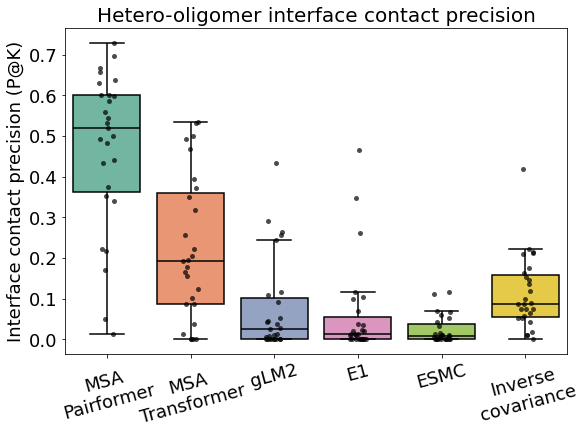

In [12]:
include_targets_l = [target for target in all_precision_d['MSA Transformer'].keys() if 'interface' in all_precision_d['MSA Transformer'][target] and not np.isnan(all_precision_d['MSA Transformer'][target]['interface'])]
# Collect data for plotting
plot_data = []
method_data = {}
include_methods_l = ["MSA Pairformer", "MSA Transformer", "gLM2", "E1", "ESMC", "Inverse covariance"]
for method in all_precision_d.keys():
    if method not in include_methods_l:
        continue
    method_data[method] = []
    for target in include_targets_l:
        precision = all_precision_d[method][target]["interface"]
        plot_data.append({
            'Method': method.replace("MSA Transformer", "MSA\nTransformer").replace("Inverse covariance", "Inverse\ncovariance").replace("MSA Pairformer", "MSA\nPairformer").replace("ESMC", "ESMC"),
            'Target': target,
            'Interface_Precision': precision
        })
        method_data[method].append(precision)

# Construct dataframe
df = pd.DataFrame(plot_data)

# Perform pairwise Wilcoxon signed-rank tests
print("Pairwise Wilcoxon signed-rank test results:")
print("=" * 50)
methods = list(df['Method'].unique()) #list(method_data.keys())
comparisons = []
p_values = []

# Collect all p-values first
for method1, method2 in combinations(methods, 2):
    method_str1 = method1.replace(" ", "\n") if method1 != 'ESMC' else 'ESMC'
    method_str2 = method2.replace(" ", "\n") if method2 != 'ESMC' else 'ESMC'
    data1 = df[df['Method'] == method_str1]['Interface_Precision'].dropna().values
    data2 = df[df['Method'] == method_str2]['Interface_Precision'].dropna().values
    statistic, p_value = wilcoxon(data1, data2, alternative='two-sided')
    comparisons.append((method1, method2, statistic, p_value))
    p_values.append(p_value)

# Apply Benjamini-Hochberg correction
rejected, p_adjusted, alpha_sidak, alpha_bonf = multipletests(p_values, method='fdr_bh')

# Print results with adjusted p-values
for i, (method1, method2, statistic, p_value) in enumerate(comparisons):
    print(f"{method1} vs {method2}:")
    print(f"  Statistic: {statistic:.2f}, p-value: {p_value:.4f}, adjusted p-value: {p_adjusted[i]:.4f}")
    if p_adjusted[i] < 0.001:
        significance = "***"
    elif p_adjusted[i] < 0.01:
        significance = "**"
    elif p_adjusted[i] < 0.05:
        significance = "*"
    else:
        significance = "n.s."
    print(f"  Significance (adjusted): {significance}")
    print()

f, ax = plt.subplots(1, 1, figsize=(9, 6))
ax = sns.boxplot(
    data=df, x='Method', y='Interface_Precision', palette='Set2', linewidth=1.5, ax=ax, showfliers=False, 
    boxprops=dict(edgecolor='black'), medianprops=dict(color='black'), whiskerprops=dict(color='black'), capprops=dict(color='black'),
    order=["MSA\nPairformer", "MSA\nTransformer", "gLM2", "E1", "ESMC", "Inverse\ncovariance"]
)
sns.stripplot(data=df, x='Method', y='Interface_Precision', color='black', size=5, alpha=0.7, ax=ax)
ax.set_title('Hetero-oligomer interface contact precision', fontsize=20)
ax.set_ylabel('Interface contact precision (P@K)', fontsize=18)
ax.set_xlabel('')
ax.tick_params(axis='x', which='major', labelsize=18, labelrotation=15)
ax.tick_params(axis='y', which='major', labelsize=18)
print(df.drop_duplicates(subset=['Method', 'Target']).groupby("Method").agg({"Interface_Precision": "median"}).sort_values(by="Interface_Precision", ascending=False))
f.savefig(f"results/figures/interface_precision_all_methods.pdf", dpi=300, bbox_inches='tight')